# NB05a - Score Generation

This notebook transforms the raw LightGBM scores produced by the upstream modelling pipeline into two conformal nonconformity score series - `score_scp` and `score_aps` - that feed conformal calibration in NB05b and downstream prediction-set evaluation in NB06.

---

## Purpose

Starting from the trained LightGBM model and the feature panel, this notebook runs model inference to obtain the
raw LightGBM scores `p_hat_raw` and then:

1. **Isotonically recalibrates** the raw model scores to obtain probability estimates
   `p_hat_cal` via the Pool Adjacent Violators Algorithm (PAVA).
2. **Computes two nonconformity scores** for every observation in the calibration and test
   splits:
   - `score_scp`: the simple probability-based split-conformal score
     `s(x, y) = 1 - p̂_cal(y | x)`;
   - `score_aps`: the randomised Adaptive Prediction Set / Generalised Inverse Quantile
     score `score_aps = p_above + p_y · (1 - U)`, `U ~ Uniform(0, 1)`,
     following Romano, Sesia & Candès (2020).
3. **Diagnoses score distributions** via Population Stability Index (PSI) and visualisations
   to check for temporal score drift between the calibration era and test splits.
4. **Writes `score_manifest.json`** - a record of selected calibration and score
   diagnostics plus score-file metadata used by downstream notebooks.

---

## Notebook Structure

| Section | Title | Description |
|---------|-------|-------------|
| §0 | Setup & Configuration | Load the panel and NB04 manifests, reconstruct the NB04 categorical encoders, configure paths, and load the LightGBM model for inference |
| §1 | Isotonic Recalibration | Fit `IsotonicRegression` on `iso_fit` (10 % hash-holdout); validate on `cp_cal` OOS sample; diagnose pre/post Brier score and AUROC |
| §2 | Score Computation | Compute `score_scp` and `score_aps` for all calibration and test splits; write per-split parquet score files |
| §3 | Score Distribution Diagnostics | Plot calibrated-probability and score distributions; compute PSI relative to the `cp_cal` base distribution |
| §4 | NB05a Artefact Manifest | Write `score_manifest.json` recording calibration diagnostics, score statistics, PSI results, and score-file inventory |
| - | Literature & Documentation Appendix | Full APA-style references for all cited works |

---

## Key Design Choices

**Hash-holdout partition within calibration.** `crc32(loan_sequence_number) % 10`: residue `0`
→ `iso_fit` (calibrator fitting), residues `1–9` → `cp_cal` (conformal calibration + score
storage). The partition is loan-level, so every monthly observation of a mortgage shares one
role, preventing loan overlap between `iso_fit` and `cp_cal`. Within-loan serial
dependence across months and chronological windows remains. Detailed methodology is in §1.

**Isotonic calibrator scope.** The calibrator is fitted once on the 2005–2006 `iso_fit` rows and
applied without refitting to all test splits. Conformal validity rests on exchangeability of
calibration and test scores, not on perfect probability calibration (Vovk et al., 2005; Shafer &
Vovk, 2008; Lei et al., 2018); residual drift is documented via §3 PSI diagnostics.

**APS score parametrisation.** Following Romano et al. (2020),
`score_aps = p_above + p_y · (1 - U)`, `U ~ Uniform(0, 1)`. For reproducibility,
draws use the deterministic split/year seed `MD5(split_name || obs_year) % 2³²`.
The binary cases are derived in §2.

**Brier score convention.** Single-class mean-squared-error form, `range [0, 1]`, consistent with `sklearn.metrics.brier_score_loss`. This utilizes a negatively oriented convention (acting as a loss function), which contrasts with the positive orientation (where higher scores are better) established in the influential characterization of proper scoring rules by Gneiting & Raftery (2007).

**PSI.** A practitioner score-drift heuristic, not a formal test. The 0.10/0.25 bands are an industry rule of thumb (Siddiqi
2017), not definitive, complemented by the asymptotic independent-multinomial reference of
Yurdakul & Naranjo (2020). Effective bin count can fall below 10 for concentrated distributions. See §3.

---
## Section 0 · Setup & Configuration

### 0.1 · Install Dependencies

In [ ]:
%pip install -q lightgbm polars pyarrow scikit-learn joblib psutil matplotlib
import lightgbm as _lgb
print(f'LightGBM {_lgb.__version__} installed')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 833.4/833.4 kB 79.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 MB 76.6 MB/s eta 0:00:00
LightGBM 4.6.0 installed


### 0.2 · Imports

In [ ]:
from __future__ import annotations

import gc, hashlib, json, os, sys, time, warnings, zlib
from datetime import datetime, timezone
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import psutil
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss, roc_auc_score
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

IS_COLAB = 'google.colab' in sys.modules or Path('/content').exists()
N_CPU    = psutil.cpu_count(logical=True)

print(f'N_CPU    : {N_CPU}')
print(f'IS_COLAB : {IS_COLAB}')

N_CPU    : 44
IS_COLAB : True


### 0.3 · Drive Mount & Path Configuration

Paths follow NB04's directory contract. NB05a uses:
- `SCORES_DIR` - ZSTD Parquet score files, one subdirectory per split
- `CP_ARTIFACTS_DIR` - calibrators and CP method artefacts

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
DRIVE_ROOT = Path('/content/drive/MyDrive/master_thesis')

# ── Inherited paths from NB04 ────────────────────────────────────
PANEL_DIR   = DRIVE_ROOT / 'data'    / 'panel'
MODELS_DIR  = DRIVE_ROOT / 'models'
RESULTS_DIR = DRIVE_ROOT / 'results'
FIGURES_DIR = RESULTS_DIR / 'nb05a' / 'figures'

# ── NB05a/05b paths ───────────────────────────────────────────────────────────
SCORES_DIR       = RESULTS_DIR  / 'scores'        # nonconformity score Parquet files
CP_ARTIFACTS_DIR = DRIVE_ROOT   / 'cp_artifacts'  # calibrators, thresholds, CP artefacts
MANIFEST_DIR = DRIVE_ROOT / 'manifests'

for _d in [SCORES_DIR, CP_ARTIFACTS_DIR, FIGURES_DIR, MANIFEST_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# ── Convenience paths ─────────────────────────────────────────────────────────
MODEL_PATH           = MODELS_DIR       / 'lgbm_model.txt'
CAT_ENCODERS_PATH    = MODELS_DIR       / 'cat_encoders.json'
CALIBRATOR_PATH      = CP_ARTIFACTS_DIR / 'isotonic_calibrator.pkl'
CALIBRATOR_META_PATH = CP_ARTIFACTS_DIR / 'isotonic_calibrator_meta.json'
SCORE_MANIFEST_PATH  = MANIFEST_DIR / 'score_manifest.json'

assert PANEL_DIR.exists(),   f'Panel directory not found: {PANEL_DIR}'
assert MODEL_PATH.exists(),  f'LightGBM model not found: {MODEL_PATH}'

print(f'DRIVE_ROOT       : {DRIVE_ROOT}')
print(f'PANEL_DIR        : {PANEL_DIR}')
print(f'SCORES_DIR       : {SCORES_DIR}')
print(f'CP_ARTIFACTS_DIR : {CP_ARTIFACTS_DIR}')
print(f'Model size       : {MODEL_PATH.stat().st_size / 1e6:.2f} MB')

Mounted at /content/drive
DRIVE_ROOT       : /content/drive/MyDrive/master_thesis
PANEL_DIR        : /content/drive/MyDrive/master_thesis/data/panel
SCORES_DIR       : /content/drive/MyDrive/master_thesis/results/scores
CP_ARTIFACTS_DIR : /content/drive/MyDrive/master_thesis/cp_artifacts
Model size       : 7.62 MB


### 0.4 · Load Manifests

NB05a inherits its complete specification from two upstream manifests:
- `panel_manifest.json` (NB03): feature columns, subgroup columns, split windows, target semantics
- `model_manifest.json` (NB04): confirmed feature list, scale_pos_weight, and the model's best iteration / validation AUROC

In [ ]:
panel_manifest_path = MANIFEST_DIR / 'panel_manifest.json'
nb04_manifest_path  = MANIFEST_DIR / 'model_manifest.json'

# panel_manifest.json is the primary upstream contract
assert panel_manifest_path.exists(), f'panel_manifest.json not found: {panel_manifest_path}'
with open(panel_manifest_path) as f:
    MANIFEST = json.load(f)

# model_manifest.json is written by NB04 to MANIFEST_DIR.
assert nb04_manifest_path.exists(), (
    f'model_manifest.json not found at {nb04_manifest_path}. '
    'Run 04_lgbm_training.ipynb first.'
)
with open(nb04_manifest_path) as f:
    MANIFEST_NB04 = json.load(f)

# ── Extract contracts ─────────────────────────────────────────────────────────
FEATURE_COLS    = MANIFEST['feature_cols']           # active model feature list (count printed below)
SUBGROUP_COLS   = MANIFEST['subgroup_cols']          # fico_tier, ltv_bucket, fico_ltv_group, census_division
TARGET_COL      = MANIFEST['target_col']             # 'y'
ALPHA           = float(MANIFEST['alpha'])           # 0.10
SPLIT_STATS     = {s['split']: s for s in MANIFEST['split_statistics']}

# ── Cross-manifest contract check ─────────────────────────────────────────────
nb04_features = MANIFEST_NB04['model']['feature_cols']
assert FEATURE_COLS == nb04_features, (
    f'Feature column mismatch between panel_manifest and model_manifest.\n'
    f'  panel_manifest: {FEATURE_COLS}\n'
    f'  nb04_manifest : {nb04_features}\n'
    f'  same set, different order: {set(FEATURE_COLS) == set(nb04_features)}'
)

# Confirm the NB04 manifest exposes the training/model keys downstream notebooks rely on.
for _section, _key in [('training', 'scale_pos_weight'),
                       ('model',    'best_iteration'),
                       ('model',    'best_val_auroc')]:
    assert _key in MANIFEST_NB04[_section], (
        f'model_manifest.json missing required key: {_section}.{_key}'
    )

print('Manifest contracts loaded and validated:')
print(f'  Active model features : {len(FEATURE_COLS)}')
print(f'  Subgroup columns      : {SUBGROUP_COLS}')
print(f'  Alpha (1 - coverage)  : {ALPHA}')
print(f'  scale_pos_weight      : {float(MANIFEST_NB04["training"]["scale_pos_weight"]):.4f}')
print(f'  Model trees           : {int(MANIFEST_NB04["model"]["best_iteration"])}')
print(f'  Val AUROC (NB04)      : {float(MANIFEST_NB04["model"]["best_val_auroc"]):.6f}')
print()
for split, stats in SPLIT_STATS.items():
    if split == 'train': continue
    print(f'  {split:<18}: {int(stats["n_rows"]):>13,} rows  pos={stats["positive_rate_pct"]:.4f}%')
print('\n✓  Cross-manifest feature contract confirmed.')

Manifest contracts loaded and validated:
  Active model features : 29
  Subgroup columns      : ['fico_tier', 'ltv_bucket', 'fico_ltv_group', 'census_division']
  Alpha (1 - coverage)  : 0.1
  scale_pos_weight      : 80.5694
  Model trees           : 646
  Val AUROC (NB04)      : 0.927109

  calibration       :   179,344,121 rows  pos=1.1075%
  test_subprime     :   633,244,002 rows  pos=2.5252%
  test_normal       :   753,732,904 rows  pos=1.5173%
  test_covid        :   201,447,058 rows  pos=1.6793%
  test_rate_hike    :   306,340,880 rows  pos=1.0427%

✓  Cross-manifest feature contract confirmed.


### 0.5 · Feature Classification & Encoder Loading

String categoricals are encoded by reloading the `cat_encoders.json` written by NB04.


In [ ]:
# String categoricals: label-encoded using the encoders fitted in NB04
CAT_FEATURES_STR = [
    'loan_purpose', 'occupancy_status', 'property_type',
    'first_time_homebuyer_flag', 'census_division',
]

# Columns written to score files (identifiers + target + subgroups + calibration role)
SCORE_PASSTHROUGH_COLS = (['loan_sequence_number', 'obs_month', 'obs_year', TARGET_COL]
                          + SUBGROUP_COLS)

# ── Load encoders from NB04 ────────────────────────────────────────────────────
assert CAT_ENCODERS_PATH.exists(), f'cat_encoders.json not found: {CAT_ENCODERS_PATH}'
with open(CAT_ENCODERS_PATH) as f:
    _enc_raw = json.load(f)

# Reconstruct LabelEncoder objects from the saved category lists
CAT_ENCODERS: dict[str, LabelEncoder] = {}
UNKNOWN_CAT_CODES: dict[str, int] = {}

for col, categories in _enc_raw.items():
    le = LabelEncoder()
    le.classes_ = np.array(categories, dtype=object)
    CAT_ENCODERS[col]      = le
    UNKNOWN_CAT_CODES[col] = len(le.classes_)  # reserved code for unseen values

# ── Load the frozen model ─────────────────────────────────────────────────────
BOOSTER = lgb.Booster(model_file=str(MODEL_PATH))
print(f'✓  LightGBM booster loaded: {BOOSTER.num_trees()} trees, '
      f'{BOOSTER.num_feature()} features')

# ── Helper: string categorical encoding ──────────────────────────────────────
def _to_str_array(series: pl.Series) -> np.ndarray:
    """Convert a Polars string series to NumPy str array, NULL → '__NULL__'."""
    return series.cast(pl.Utf8).fill_null('__NULL__').to_numpy().astype(str)


def encode_cats_inplace(df: pl.DataFrame) -> pl.DataFrame:
    """
    Apply NB04-fitted label encoders to string categoricals.
    Returns a new DataFrame with string columns replaced by int32 codes.
    Unseen values in these string-categorical fields map to unknown_code = n_classes.
    census_division is encoded for model input but the original string column is preserved
    separately via SCORE_PASSTHROUGH_COLS (which reads from the unmodified load).
    """
    exprs = []
    for col in CAT_FEATURES_STR:
        if col not in df.columns:
            continue
        le       = CAT_ENCODERS[col]
        unk_code = UNKNOWN_CAT_CODES[col]
        code_map = {cls: i for i, cls in enumerate(le.classes_)}

        vals  = _to_str_array(df[col])
        codes = np.fromiter(
            (code_map.get(v, unk_code) for v in vals),
            dtype=np.int32,
            count=len(vals),
        )
        exprs.append(pl.Series(col, codes, dtype=pl.Int32))

    # Replace string columns with integer codes (for feature matrix only)
    for s in exprs:
        df = df.with_columns(s)
    return df


print('\n✓  Categorical encoders reconstructed from NB04 cat_encoders.json:')
for col, le in CAT_ENCODERS.items():
    print(f'   {col:<28} classes={len(le.classes_)}  unknown_code={UNKNOWN_CAT_CODES[col]}')
print(f'\n✓  FEATURE_COLS ({len(FEATURE_COLS)} features): {FEATURE_COLS}')
print(f'\n  Forbidden features in FEATURE_COLS:')
for forbidden in ['channel', 'deferred_upb_ratio', 'in_workout_plan_flag']:
    status = '✓ absent' if forbidden not in FEATURE_COLS else '✗ PRESENT - contract violation'
    print(f'   {forbidden:<28}: {status}')

✓  LightGBM booster loaded: 646 trees, 29 features

✓  Categorical encoders reconstructed from NB04 cat_encoders.json:
   loan_purpose                 classes=4  unknown_code=4
   occupancy_status             classes=3  unknown_code=3
   property_type                classes=6  unknown_code=6
   first_time_homebuyer_flag    classes=3  unknown_code=3
   census_division              classes=9  unknown_code=9

✓  FEATURE_COLS (29 features): ['cltv_missing', 'dti_missing', 'dti_missing_non_relief_refi', 'fico_missing', 'is_30dpd_at_t', 'is_multi_borrower', 'ltv_missing', 'first_time_homebuyer_flag', 'occupancy_status', 'number_of_units', 'loan_purpose', 'vintage_quarter', 'property_type', 'vintage_year', 'census_division', 'months_since_last_dlq', 'n_times_30dpd_last_12m', 'max_dlq_last_12m', 'original_dti', 'original_ltv', 'rate_spread', 'original_cltv', 'original_loan_term', 'credit_score', 'original_upb', 'original_interest_rate', 'current_interest_rate', 'current_upb', 'upb_rel_change_3

---
## Section 1 · Isotonic Recalibration

### Motivation and Literature

The frozen predictor is a LightGBM gradient-boosted decision-tree model, rooted in Friedman's
function-approximation view of boosting and using the scalable GBDT implementation of Ke et al.
(Friedman, 2001; Ke et al., 2017). It was trained with a large positive-class weight
(`scale_pos_weight`, loaded from the NB04 manifest; see §0.4) to address severe class imbalance
(He & Garcia, 2009; see NB04). Elkan (2001) provides the broader cost-sensitive framework -
optimal decisions minimise expected cost from class-posterior probabilities and a cost matrix -
and notes that for tree and Bayesian methods cost sensitivity is often better achieved by
estimating probabilities and adjusting the decision threshold than by rebalancing base rates.
`scale_pos_weight` is therefore treated as an implementation-level training reweighting, not as
Elkan's preferred decision rule; the LightGBM documentation is the source for its behaviour and
for the warning that class-weighting parameters can degrade individual probability estimates
(LightGBM Developers, n.d.).

Gradient-boosted classifiers can produce poorly calibrated probabilities, and post-hoc isotonic
recalibration can improve them when calibration data are plentiful (Zadrozny & Elkan, 2002;
Niculescu-Mizil & Caruana, 2005). Niculescu-Mizil and Caruana (2005) study boosted-tree
calibration rather than this LightGBM specification; here, LightGBM's documentation warns that
`scale_pos_weight` can impair individual probability estimates, without identifying how much
of the observed distortion it causes.

Conformal marginal validity does **not** require calibrated probabilities: the guarantee is an
exchangeability result for calibration and test scores, not a statement about the semantic
correctness of the model probabilities (Vovk et al., 2005; Shafer & Vovk, 2008; Lei et al.,
2018). This is marginal (unconditional) coverage; conditional validity for inductive conformal
predictors is treated by Vovk (2012). Calibration nonetheless matters here because (i) the
APS/GIQ score is built from cumulative sorted probability mass, so its adaptivity, efficiency,
and class-specific behaviour depend on the probability vector (Romano et al., 2020), and (ii)
mean-score and PSI-style drift diagnostics are easier to interpret on a probability scale than on
a raw class-weighted LightGBM score. The calibrator is fitted once on the 2005–2006 `iso_fit`
rows and applied without refitting to all later test eras. Under temporal shift the
`p_raw → p_cal` mapping may no longer match empirical frequencies; §3 documents
score-distribution movement, not probability-calibration error. That possibility does not
by itself invalidate SCP-family conformal inference.

### Method: Isotonic Regression / PAVA

Isotonic regression fits a non-parametric monotone non-decreasing mapping `p_cal = f(p_raw)` via
the Pool Adjacent Violators Algorithm (PAVA), with Ayer et al. (1955) as the classical origin and
Barlow et al. (1972) as the standard monograph. The `out_of_bounds='clip'` setting clips raw
scores outside the fitted domain to the nearest boundary value (scikit-learn Developers, n.d.).
Given the very large `iso_fit` sample, isotonic regression is a defensible recalibration
choice - practical here, not claimed to be universally optimal for gradient-boosted trees.

### Calibration Diagnostics

The scalar probability-quality metric is the single-class Brier score (range [0, 1]):

`BS = (1/n) Σ_i (p̂_i - y_i)²`.

Brier (1950) introduced the probability score, and the formulation above is consistent with `sklearn.metrics.brier_score_loss`. As a strictly proper scoring rule, it evaluates probabilistic forecasts rather than only hard classifications. Reliability diagrams give the visual counterpart, comparing mean predicted probability with empirical event frequency per bin, with Guo et al. (2017) as the modern binned-diagnostic reference. AUROC is reported only as a rank-discrimination sanity check: monotone recalibration should largely preserve ranking, but flat isotonic segments create ties, so a small AUROC delta is acceptable and is a diagnostic rather than a conformal-validity condition (Fawcett, 2006).

## Recalibration rationale: why isotonic, and why it is retained downstream

NB04 established that the class-weighted training objective produces a faithful
risk *ranking* on a distorted *scale* (ECE = 0.1471; mean predicted 0.1583 vs
observed 0.0112). This section corrects the scale. The choice of method and the
necessity of the step both warrant explicit justification.

**Why isotonic regression specifically.** Isotonic regression fits a monotone
non-decreasing recalibration function. PAVA pools adjacent fitted levels, while
scikit-learn predicts between retained threshold points by linear interpolation.
It is non-parametric (no logistic/Platt link assumption imposing a sigmoid shape),
preserves score ordering up to ties, and requires no refitting of the model. The
out-of-sample diagnostics confirm the intended scale correction: Brier improves
0.0643 → 0.0086 while AUROC changes by only −0.00006.

**Why recalibration is retained downstream.** Recalibration is not required for
the conformal marginal-coverage guarantee, and APS does not require perfectly
calibrated class probabilities for that guarantee. It is nevertheless useful in
this pipeline for three reasons:

1. *The operational layer (NB09).* Routing thresholds are interpreted on the
   calibration-era probability scale rather than on model-specific weighted scores.
2. *The cross-model benchmark (NB10).* LightGBM (`scale_pos_weight`) and the
   logistic-regression benchmark (`class_weight='balanced'`) produce differently
   distorted raw scales. Recalibrating both provides a common interpretable scale
   for score-level and threshold comparisons.
3. *The APS nonconformity score.* APS accumulates the estimated class-probability
   vector. Better probability estimates support the intended adaptive
   interpretation and efficiency of that score, while its conformal marginal
   validity still comes from held-out score calibration rather than probability
   calibration itself.

**Scope of this step.** Recalibration is adopted for interpretability and
cross-model comparability of the score *level*. It is not adopted to improve
conformal coverage; under exchangeability, conformal calibration gives marginal
validity for any fixed score, regardless of probability calibration. The interaction
between recalibration and class-conditional conformal coverage is a separate
question, assessed on the logistic benchmark in NB10 §6.

### 1.0 · Inference on iso_fit Subset

The calibration split Parquet files are scanned lazily. For each observation year
(2005 and 2006) the iso_fit partition (`crc32(loan_sequence_number) % 10 == 0`) is selected
in-memory and scored with the frozen booster. This gives the (p_hat_raw, y) pairs used to fit the isotonic calibrator in §1.1.
The actual row count (`N_ISO_FIT`) is reported at runtime.


In [ ]:
CAL_DIR = PANEL_DIR / 'split=calibration'
assert CAL_DIR.exists(), f'Calibration split not found: {CAL_DIR}'

# Columns needed for isotonic fitting: features + target
# Subgroup cols not needed here; we only need p_hat_raw and y
ISO_LOAD_COLS = FEATURE_COLS + [TARGET_COL, 'loan_sequence_number', 'obs_year']

# Collect all p_hat_raw and y from iso_fit rows
iso_p_raw_list: list[np.ndarray] = []
iso_y_list:     list[np.ndarray] = []

cal_parquet_files = sorted(CAL_DIR.glob('*.parquet'))
print(f'Calibration split Parquet files : {len(cal_parquet_files)}')
print('Scanning for iso_fit rows (crc32(loan_sequence_number) % 10 == 0) ...')

t0 = time.time()

for obs_year in [2005, 2006]:
    # Lazy scan with year predicate pushdown
    df_year = (
        pl.scan_parquet(str(CAL_DIR / '*.parquet'))
        .filter(pl.col('obs_year') == obs_year)
        .select(ISO_LOAD_COLS)
        .collect()
    )

    if len(df_year) == 0:
        print(f'  {obs_year}: no rows found - skipping')
        continue

    # ── Deterministic loan-level iso_fit partition ────────────────────────
    # crc32 is stable across Python versions and machines (unlike hash()).
    # A loan always lands in the same partition regardless of session order.
    lsn_bytes = df_year['loan_sequence_number'].cast(pl.Utf8).to_list()
    is_iso    = np.array(
        [zlib.crc32(s.encode()) % 10 == 0 for s in lsn_bytes], dtype=bool
    )
    df_iso = df_year.filter(pl.Series('_iso', is_iso))

    if len(df_iso) == 0:
        continue

    # ── Categorical encoding for model input ──────────────────────────────
    df_enc = encode_cats_inplace(df_iso)

    # ── Build feature matrix: FEATURE_COLS only, correct order ────────────
    X = df_enc.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float64)

    # ── LightGBM inference (all CPUs) ─────────────────────────────────────
    # predict_disable_shape_check=True is safe: feature ordering is enforced
    # by the FEATURE_COLS contract from NB04 via panel_manifest.json (§0.4).
    p_hat_raw = BOOSTER.predict(
        X, num_threads=N_CPU, predict_disable_shape_check=True
    ).astype(np.float64)

    iso_p_raw_list.append(p_hat_raw)
    iso_y_list.append(df_iso[TARGET_COL].to_numpy())

    n_iso_yr = len(df_iso)
    pos_rate = float(df_iso[TARGET_COL].mean() * 100)
    print(f'  {obs_year}: {len(df_year):>10,} total rows  |  '
          f'{n_iso_yr:>8,} iso_fit rows  |  pos={pos_rate:.4f}%')

    del df_year, df_iso, df_enc, X
    gc.collect()

# ── Concatenate iso_fit arrays ─────────────────────────────────────────────
iso_p_raw_all = np.concatenate(iso_p_raw_list)
iso_y_all     = np.concatenate(iso_y_list)
N_ISO_FIT     = len(iso_p_raw_all)

del iso_p_raw_list, iso_y_list
gc.collect()

elapsed = time.time() - t0
print(f'\niso_fit collected: {N_ISO_FIT:,} rows  |  '
      f'pos_rate={iso_y_all.mean()*100:.4f}%  |  {elapsed:.0f}s')

Calibration split Parquet files : 1
Scanning for iso_fit rows (crc32(loan_sequence_number) % 10 == 0) ...
  2005: 86,482,468 total rows  |  8,642,782 iso_fit rows  |  pos=1.1256%
  2006: 92,861,653 total rows  |  9,279,373 iso_fit rows  |  pos=1.0916%

iso_fit collected: 17,922,155 rows  |  pos_rate=1.1080%  |  499s


### 1.1 · Fit Isotonic Calibrator

`IsotonicRegression` fits the monotone `p_raw → p_cal` mapping by PAVA on the `iso_fit` pairs,
with `out_of_bounds='clip'` clipping out-of-domain raw scores to the nearest fitted boundary.
The in-sample Brier score improves by construction because the mapping is fitted on these rows,
so the out-of-sample `cp_cal` check in §1. is the validation that matters; AUROC is recorded as
a ranking sanity check. Method and references are in §1.

In [ ]:
BRIER_BEFORE = float(brier_score_loss(iso_y_all, iso_p_raw_all))

# ── Fit calibrator on iso_fit (p_hat_raw, y) pairs (PAVA; see §1) ──
print('Fitting IsotonicRegression on iso_fit (p_hat_raw, y) pairs ...')
t0 = time.time()

ISO_CALIBRATOR = IsotonicRegression(out_of_bounds='clip')
ISO_CALIBRATOR.fit(iso_p_raw_all, iso_y_all)

elapsed = time.time() - t0
n_breakpoints = len(ISO_CALIBRATOR.f_.x)  # number of PAVA breakpoints
print(f'✓  Fitted in {elapsed:.1f}s  |  PAVA breakpoints: {n_breakpoints:,}')

# ── In-sample Brier (diagnostic only; improves by construction, see §1) ──
iso_p_cal_insample = ISO_CALIBRATOR.predict(iso_p_raw_all)
BRIER_AFTER_INSAMPLE = float(brier_score_loss(iso_y_all, iso_p_cal_insample))

# ── AUROC delta: in-sample ranking sanity check (rationale in §1) ──
auroc_raw = roc_auc_score(iso_y_all, iso_p_raw_all)
auroc_cal = roc_auc_score(iso_y_all, iso_p_cal_insample)
AUROC_DELTA = float(auroc_cal - auroc_raw)

print(f'  Brier score before (iso_fit) : {BRIER_BEFORE:.6f}')
print(f'  Brier score after  (iso_fit) : {BRIER_AFTER_INSAMPLE:.6f}  (in-sample fitted diagnostic)')
print(f'  AUROC raw  (iso_fit)         : {auroc_raw:.6f}')
print(f'  AUROC cal  (iso_fit)         : {auroc_cal:.6f}')
print(f'  AUROC delta                  : {AUROC_DELTA:+.6f}  (ranking sanity check; small tie effects possible)')

# ── iso_fit positive-rate parity check (guards against a biased hash sample) ──
iso_pos_rate  = float(iso_y_all.mean() * 100)
cal_pos_rate  = float(SPLIT_STATS['calibration']['positive_rate_pct'])
print(f'\n  iso_fit positive rate  : {iso_pos_rate:.4f}%')
print(f'  calibration split rate : {cal_pos_rate:.4f}%  (expected ≈ iso_fit rate)')

# Illustrate the empirical recalibration mapping; do not interpret this as a
# formal inverse correction for scale_pos_weight.
p_test_points = np.array([0.01, 0.05, 0.10, 0.30, 0.50, 0.70, 0.90])
p_cal_points  = ISO_CALIBRATOR.predict(p_test_points)
print('\n  empirical isotonic recalibration mapping illustrated:')
print('  p_raw  →  p_cal')
for pr, pc in zip(p_test_points, p_cal_points):
    print(f'  {pr:.2f}    →  {pc:.6f}')

# ── Serialise calibrator and metadata to Drive ─────────────────────────────
joblib.dump(ISO_CALIBRATOR, CALIBRATOR_PATH, compress=3)

# Metadata written first so that the gate (§1.0) can check both files
_meta_pre = {
    'fitted_at'                 : datetime.now(tz=timezone.utc).isoformat(),
    'n_iso_fit'                 : N_ISO_FIT,
    'n_cp_cal'                  : 'pending_section_1_3',  # updated in §1.3
    'n_breakpoints'             : n_breakpoints,
    'brier_score_before'        : round(BRIER_BEFORE, 8),
    'brier_score_after_insample': round(BRIER_AFTER_INSAMPLE, 8),
    'brier_score_after_oos'     : 'pending_section_1_3',  # updated in §1.3
    'auroc_raw'                 : round(float(auroc_raw), 8),
    'auroc_after'               : round(float(auroc_cal), 8),
    'auroc_delta'               : round(AUROC_DELTA, 8),
    'iso_fit_hash_rule'         : 'crc32(loan_sequence_number) % 10 == 0',
    'iso_fit_fraction'          : 0.10,
    'calibrator_path'           : str(CALIBRATOR_PATH),
}
with open(CALIBRATOR_META_PATH, 'w') as f:
    json.dump(_meta_pre, f, indent=2)

print(f'\n✓  Calibrator serialised to {CALIBRATOR_PATH}')
del iso_p_raw_all, iso_y_all, iso_p_cal_insample
gc.collect()

Fitting IsotonicRegression on iso_fit (p_hat_raw, y) pairs ...
✓  Fitted in 5.4s  |  PAVA breakpoints: 516
  Brier score before (iso_fit) : 0.064165
  Brier score after  (iso_fit) : 0.008663  (in-sample fitted diagnostic)
  AUROC raw  (iso_fit)         : 0.911277
  AUROC cal  (iso_fit)         : 0.911422
  AUROC delta                  : +0.000145  (ranking sanity check; small tie effects possible)

  iso_fit positive rate  : 1.1080%
  calibration split rate : 1.1075%  (expected ≈ iso_fit rate)

  empirical isotonic recalibration mapping illustrated:
  p_raw  →  p_cal
  0.01    →  0.000363
  0.05    →  0.001440
  0.10    →  0.002985
  0.30    →  0.009569
  0.50    →  0.017836
  0.70    →  0.035750
  0.90    →  0.137322

✓  Calibrator serialised to /content/drive/MyDrive/master_thesis/cp_artifacts/isotonic_calibrator.pkl


33

### 1.3 · Out-of-Sample Validation on cp_cal

An out-of-sample loan-level sample of `cp_cal` - `crc32 % 10 != 0` (not in `iso_fit`) and
`crc32 % 50 == 1`, i.e. ≈ 1/45 of `cp_cal` - validates the calibrator on rows it was not fitted
on. This OOS Brier score is the headline recalibration check; a reliability diagram provides the
visual diagnostic and AUROC is reported as a ranking sanity check (see §1).

OOS validation on cp_cal sample (3,580,221 rows):
  Brier score before (OOS) : 0.064263
  Brier score after  (OOS) : 0.008616
  AUROC delta (OOS)        : -0.000060

✓  AUROC sanity check passed: |delta| < 0.0050 - ranking largely preserved.


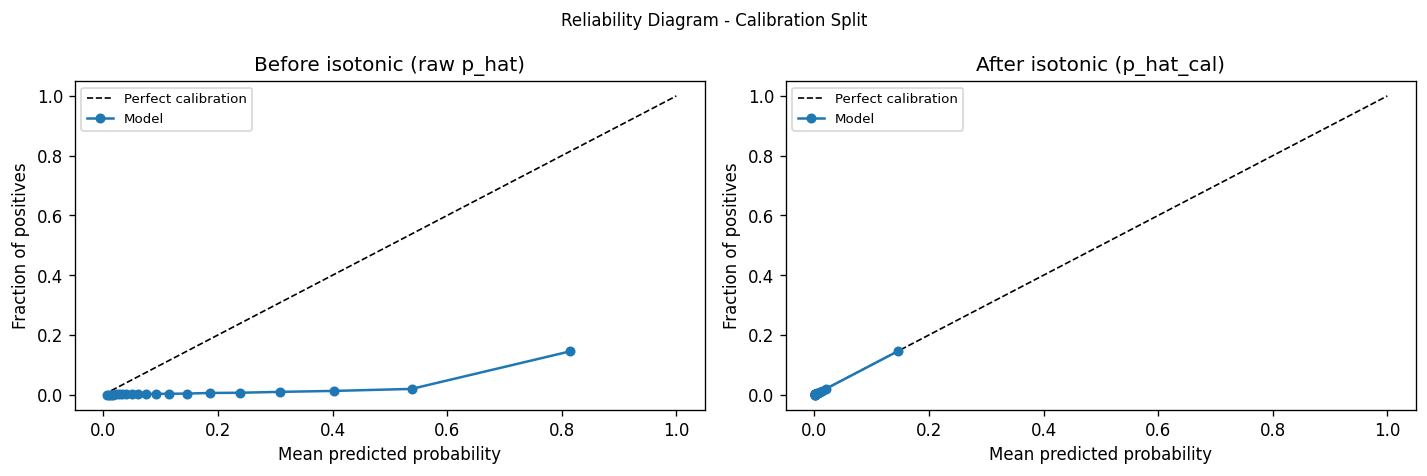


✓  Reliability diagram saved to /content/drive/MyDrive/master_thesis/results/nb05a/figures/reliability_diagram_nb05a.png
✓  Calibrator metadata updated at /content/drive/MyDrive/master_thesis/cp_artifacts/isotonic_calibrator_meta.json


42

In [ ]:
CAL_DIR = PANEL_DIR / 'split=calibration'
SAMPLE_COLS = FEATURE_COLS + [TARGET_COL, 'loan_sequence_number']

oos_p_raw_list, oos_p_cal_list, oos_y_list = [], [], []

N_CP_CAL = 0

for obs_year in [2005, 2006]:
    df_year = (
        pl.scan_parquet(str(CAL_DIR / '*.parquet'))
        .filter(pl.col('obs_year') == obs_year)
        .select(SAMPLE_COLS)
        .collect()
    )

    lsn_bytes = df_year['loan_sequence_number'].cast(pl.Utf8).to_list()
    crc_vals  = np.array([zlib.crc32(s.encode()) for s in lsn_bytes], dtype=np.int64)

    # cp_cal: NOT in iso_fit (crc % 10 != 0).
    # OOS sample: crc % 50 == 1; nominally 1/50 of all loans, i.e. ≈ 1/45 ≈ 2.2% of cp_cal
    # under approximately uniform CRC32 residues (cp_cal occupies 45/50 residue classes).
    is_cp_cal     = (crc_vals % 10) != 0
    is_oos_sample = is_cp_cal & ((crc_vals % 50) == 1)

    # Count cp_cal total for metadata before the OOS-subsample gate, so the count is
    # independent of whether this year contributes any OOS-sample rows.
    N_CP_CAL += int(is_cp_cal.sum())

    df_oos = df_year.filter(pl.Series('_s', is_oos_sample))

    if len(df_oos) == 0:
        continue

    df_enc = encode_cats_inplace(df_oos)
    X = df_enc.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float64)

    # shape-check disabled; feature-order contract enforced in §0.4 (see §1.1).
    p_raw = BOOSTER.predict(X, num_threads=N_CPU, predict_disable_shape_check=True)
    p_cal = ISO_CALIBRATOR.predict(p_raw)

    oos_p_raw_list.append(p_raw)
    oos_p_cal_list.append(p_cal)
    oos_y_list.append(df_oos[TARGET_COL].to_numpy())

    del df_year, df_oos, df_enc, X
    gc.collect()

oos_p_raw = np.concatenate(oos_p_raw_list)
oos_p_cal = np.concatenate(oos_p_cal_list)
oos_y     = np.concatenate(oos_y_list)

BRIER_BEFORE_OOS = float(brier_score_loss(oos_y, oos_p_raw))
BRIER_AFTER_OOS  = float(brier_score_loss(oos_y, oos_p_cal))
auroc_raw_oos   = roc_auc_score(oos_y, oos_p_raw)
auroc_cal_oos   = roc_auc_score(oos_y, oos_p_cal)
AUROC_DELTA     = float(auroc_cal_oos - auroc_raw_oos)

print(f'OOS validation on cp_cal sample ({len(oos_y):,} rows):')
print(f'  Brier score before (OOS) : {BRIER_BEFORE_OOS:.6f}')
print(f'  Brier score after  (OOS) : {BRIER_AFTER_OOS:.6f}')
print(f'  AUROC delta (OOS)        : {AUROC_DELTA:+.6f}')

# AUROC ranking sanity check (rationale in §1). A monotone recalibration preserves
# positive-negative ordering except where flat isotonic regions create cross-class ties;
# a large delta would therefore signal an implementation problem.
assert abs(AUROC_DELTA) < 5e-3, (
    f'Isotonic recalibration changed AUROC by {AUROC_DELTA:+.6f}. '
    'This exceeds the 0.0050 sanity tolerance for a monotone recalibration.'
)
print('\n✓  AUROC sanity check passed: |delta| < 0.0050 - ranking largely preserved.')

# ── Reliability diagram: before vs after ───────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, probs, title in zip(
    axes,
    [oos_p_raw, oos_p_cal],
    ['Before isotonic (raw p_hat)', 'After isotonic (p_hat_cal)']
):
    frac_pos, mean_pred = calibration_curve(oos_y, probs, n_bins=20, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect calibration')
    ax.plot(mean_pred, frac_pos, 'o-', ms=5, label='Model')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle(
    'Reliability Diagram - Calibration Split',
    fontsize=10
)
plt.tight_layout()
fig_path = FIGURES_DIR / 'reliability_diagram_nb05a.png'
fig.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n✓  Reliability diagram saved to {fig_path}')

# ── Update calibrator metadata with OOS Brier score ────────────────────────
with open(CALIBRATOR_META_PATH) as f:
    _meta = json.load(f)
_meta['brier_score_before_oos'] = round(BRIER_BEFORE_OOS, 8)
_meta['brier_score_after_oos'] = round(BRIER_AFTER_OOS, 8)
_meta['auroc_delta']           = round(AUROC_DELTA, 8)
_meta['n_cp_cal']              = N_CP_CAL
_meta['oos_sample_size']       = int(len(oos_y))
with open(CALIBRATOR_META_PATH, 'w') as f:
    json.dump(_meta, f, indent=2)

print(f'✓  Calibrator metadata updated at {CALIBRATOR_META_PATH}')
SECTION_1_DONE = True

del oos_p_raw_list, oos_p_cal_list, oos_y_list, oos_p_raw, oos_p_cal, oos_y
gc.collect()

---
## Section 2 · Score File Generation

This section applies the frozen LightGBM model and the isotonic calibrator to all five
splits, computing two nonconformity scores per observation:

1. **`score_scp`** - a simple probability-based classification nonconformity score,

   `s(x, y) = 1 - p̂_cal(y | x)`.

   For binary classification, this equals `p̂_cal` when `y = 0` and `1 - p̂_cal`
   when `y = 1`. The split/inductive use of a held-out calibration set follows the
   conformal prediction literature (Papadopoulos et al., 2002; Vovk et al., 2005;
   Shafer & Vovk, 2008; Lei et al., 2018). The conformal guarantee does not require
   this score to be uniquely standard or optimal; under exchangeability, validity follows
   from conformal calibration of any fixed nonconformity score. The classification-specific
   set-valued interpretation is connected to Sadinle et al. (2019), while the APS/GIQ
   score used separately below is grounded in Romano et al. (2020).

2. **`score_aps`** - randomized APS / GIQ score following Romano, Sesia, and Candès (2020).

   Let `p_y = p̂_cal(y | x)` be the fitted probability of the true class, and let
   `p_above` denote the total fitted probability mass of labels ranked strictly above the
   true class. In binary classification, `p_above = 0` if the true class is top-ranked and
   `p_above = 1 - p_y` otherwise. With `U ~ Uniform(0, 1)`, the Romano et al. GIQ score is

   `score_aps = p_above + p_y · (1 - U)`.

   Equivalently, substituting `p_above = 0` (top-ranked) and `p_above = 1 - p_y`
   (bottom-ranked) into the binary case:
   - if the true class is top-ranked:    `score_aps = p_y · (1 - U)`;
   - if the true class is bottom-ranked: `score_aps = (1 - p_y) + p_y · (1 - U)  =  1 - p_y · U`.

   The alternative `p_above + U · p_y` has the same marginal
   distribution because `U` and `1 - U` are identically distributed, but it is not the
   literal parametrization in Romano et al. (2020). This notebook uses the `1 - U`
   parametrization so that the implementation matches the cited APS/GIQ construction.

### 2.1 · Score Computation Helpers

In [ ]:
def compute_score_scp(p_hat_cal: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Simple probability-based split-conformal nonconformity score for binary classification.

    s(x, y) = 1 - p_hat_cal(true class | x)
      - For y=0: s = 1 - (1 - p_hat_cal) = p_hat_cal
      - For y=1: s = 1 - p_hat_cal

    The conformal guarantee does not require this score to be uniquely standard or
    optimal. Under exchangeability, validity follows from conformal calibration of any
    fixed nonconformity score. The probability-based form is used because it is
    interpretable and compatible with the downstream set-valued classification framing.

    References:
        - Vovk, Gammerman & Shafer (2005) and Shafer & Vovk (2008) for
          conformal prediction foundations and nonconformity-score logic.
        - Papadopoulos et al. (2002) for the inductive/split conformal architecture.
        - Lei et al. (2018) for modern split conformal finite-sample marginal validity.
        - Sadinle et al. (2019) for set-valued classification with bounded error.
        - Romano et al. (2020) for classification-specific conformal prediction sets
          and the APS/GIQ score used separately in compute_score_aps.

    Parameters
    ----------
    p_hat_cal : np.ndarray, shape (n,)
        Isotonically recalibrated P(y=1 | x), float64.
    y : np.ndarray, shape (n,)
        True binary labels (0 or 1).

    Returns
    -------
    np.ndarray, float32
    """
    s = np.where(y == 1, 1.0 - p_hat_cal, p_hat_cal)
    return s.astype(np.float32)


def compute_score_aps(
    p_hat_cal: np.ndarray,
    y: np.ndarray,
    batch_seed: int,
) -> np.ndarray:
    """
    Randomized APS / generalized inverse quantile (GIQ) score for binary classification.

    This implementation follows the Romano, Sesia & Candès (2020) GIQ parametrization.
    For a candidate true label y, let

        p_y     = p_hat_cal(y | x)
        p_above = total fitted probability mass of labels ranked strictly above y

    Then the randomized GIQ score is

        score_aps = p_above + p_y * (1 - U),      U ~ Uniform(0, 1).

    In binary classification (p_above = 1 - p_y when bottom-ranked):
      - if y is top-ranked:    score_aps = p_y * (1 - U);
      - if y is bottom-ranked: score_aps = (1 - p_y) + p_y * (1 - U)  =  1 - p_y * U.

    Note:
        The alternative p_above + U * p_y is distributionally equivalent but is not the
        literal Romano et al. (2020) parametrization; (1-U) is used so code and citation match.

    References:
        Romano, Sesia & Candès (2020), "Classification with Valid and Adaptive Coverage",
        generalized inverse quantile conformity score, Eq. (7) and Algorithm 1.

    Parameters
    ----------
    p_hat_cal : np.ndarray, shape (n,)
        Isotonically recalibrated P(y=1 | x), float64.
    y : np.ndarray, shape (n,)
        True binary labels (0 or 1).
    batch_seed : int
        Deterministic seed for this (split, obs_year) batch, derived via batch_seed_for().
        Ensures identical U values on every re-run of the same batch.

    Returns
    -------
    np.ndarray, float32
    """
    rng = np.random.default_rng(seed=batch_seed)

    p1 = np.asarray(p_hat_cal, dtype=np.float64)
    y_arr = np.asarray(y, dtype=np.int8)

    p0 = 1.0 - p1
    p_true  = np.where(y_arr == 1, p1, p0)
    p_other = 1.0 - p_true

    # The true class is top-ranked iff its fitted probability >= the other class probability.
    # Exact 0.5/0.5 ties are top-ranked here; Romano et al. (2020) suggest random tie-breaking.
    true_is_top_ranked = p_true >= p_other

    u = rng.random(len(p_true), dtype=np.float64)

    score = np.where(
        true_is_top_ranked,
        p_true * (1.0 - u),
        p_other + p_true * (1.0 - u),
    )

    return score.astype(np.float32)


def batch_seed_for(split_name: str, obs_year: int) -> int:
    """
    Deterministic seed derived from (split_name, obs_year) via MD5.
    Stable across Python versions, machines, and session order.
    """
    key = f'{split_name}_{obs_year}'.encode()
    return int(hashlib.md5(key).hexdigest(), 16) % (2 ** 32)


print('✓  Score computation helpers defined:')
print('   compute_score_scp  - simple probability-based score: 1 - p_hat_cal(true class)  [Vovk et al. 2005; Shafer & Vovk 2008]')
print('   compute_score_aps  - APS/GIQ score: p_above + p_y * (1-U)  [Romano et al. 2020, Eq. 7 / Algorithm 1]')
print('   batch_seed_for     - deterministic (split, year) seed via MD5')

# ── Unit tests ───────────────────────────────────────────────────────────────

# --- score_scp ---
_p = np.array([0.9, 0.1, 0.6, 0.4])
_y = np.array([1,   0,   1,   0  ])
_s_scp = compute_score_scp(_p, _y)
assert np.allclose(_s_scp, [0.1, 0.1, 0.4, 0.4], atol=1e-6), 'score_scp unit test failed'

# --- score_aps: all four binary (y, rank) cases across 6 rows; per-row labels inline below ---
# U values from np.random.default_rng(42).random(6):
#   U     = [0.77395605, 0.43887844, 0.85859792, 0.69736803, 0.09417735, 0.97562235]
#   (1-U) = [0.22604395, 0.56112156, 0.14140208, 0.30263197, 0.90582265, 0.02437765]
_p6 = np.array([0.9,  0.1,  0.6,  0.4,  0.3,  0.8])
_y6 = np.array([1,    0,    1,    0,    1,    0   ])
_expected_aps = np.array([
    0.22604395 * 0.9,                      # y1_top: (1-U) * p1
    0.56112156 * 0.9,                      # y0_top: (1-U) * p0
    0.14140208 * 0.6,                      # y1_top: (1-U) * p1
    0.30263197 * 0.6,                      # y0_top: (1-U) * p0
    0.7 + 0.90582265 * 0.3,               # y1_bot: p0 + (1-U) * p1
    0.8 + 0.02437765 * 0.2,               # y0_bot: p1 + (1-U) * p0
])
_s_aps6 = compute_score_aps(_p6, _y6, batch_seed=42)
assert np.allclose(_s_aps6, _expected_aps, atol=1e-7), (
    f'APS unit test failed.\n  expected: {_expected_aps}\n  got:      {_s_aps6}'
)
# Bottom-ranked cases must satisfy score >= probability of higher-ranked class
assert _s_aps6[4] >= 0.7, f'y1_bot score must be >= p0=0.7, got {_s_aps6[4]}'
assert _s_aps6[5] >= 0.8, f'y0_bot score must be >= p1=0.8, got {_s_aps6[5]}'
# All scores must be in [0, 1]
assert np.all((_s_aps6 >= 0.0) & (_s_aps6 <= 1.0 + 1e-9)), 'APS scores out of [0, 1]'
print('\n✓  Unit tests passed for compute_score_scp and compute_score_aps')

✓  Score computation helpers defined:
   compute_score_scp  - simple probability-based score: 1 - p_hat_cal(true class)  [Vovk et al. 2005; Shafer & Vovk 2008]
   compute_score_aps  - APS/GIQ score: p_above + p_y * (1-U)  [Romano et al. 2020, Eq. 7 / Algorithm 1]
   batch_seed_for     - deterministic (split, year) seed via MD5

✓  Unit tests passed for compute_score_scp and compute_score_aps


### 2.2 · Generation Loop

Processes splits in order: calibration → test_subprime → test_normal → test_covid → test_rate_hike.
For each split, processes one `obs_year` at a time. Calibration rows are additionally tagged with
`iso_role` ('iso_fit' or 'cp_cal') for use in NB05b's CP threshold computation.

An idempotency check at the start of each split skips it if the expected total row count
already matches the panel manifest (session-resumable at split granularity).


In [ ]:
# Ordered list of splits to score and their obs_year ranges
SPLITS_TO_SCORE = [
    ('calibration',    [2005, 2006]),
    ('test_subprime',  list(range(2007, 2013))),
    ('test_normal',    list(range(2013, 2020))),  # ends 2019-09-30
    ('test_covid',     [2020, 2021]),
    ('test_rate_hike', [2022, 2023]),
]

# Columns read from panel for scoring: features + identifiers + subgroups + target
SCORE_LOAD_COLS = list(dict.fromkeys(
    FEATURE_COLS
    + ['loan_sequence_number', 'obs_month', 'obs_year', TARGET_COL]
    + SUBGROUP_COLS
))

# Track row counts written per split for validation in §2.3
WRITTEN_ROW_COUNTS: dict[str, int] = {}

t_total = time.time()

for split_name, years in SPLITS_TO_SCORE:

    split_dir    = PANEL_DIR / f'split={split_name}'
    out_dir      = SCORES_DIR / f'split={split_name}'
    out_dir.mkdir(parents=True, exist_ok=True)

    # ── Idempotency: skip if already complete ─────────────────────────────────
    expected_rows = SPLIT_STATS[split_name]['n_rows']
    existing_files = sorted(out_dir.glob('*.parquet'))
    if existing_files:
        # Count rows in existing score files
        existing_n = sum(
            pl.scan_parquet(str(f)).select(pl.len()).collect().item()
            for f in existing_files
        )
        if existing_n == expected_rows:
            print(f'⏭  {split_name:<18}: {existing_n:,} rows already on Drive - skipping.')
            WRITTEN_ROW_COUNTS[split_name] = existing_n
            continue
        else:
            print(f'⚠  {split_name}: found {existing_n:,} rows but expected {expected_rows:,} - regenerating.')
            for f in existing_files:
                f.unlink()

    print(f'\n── {split_name} ({len(years)} years, {expected_rows:,} expected rows) ──')

    is_calibration = (split_name == 'calibration')
    split_row_count = 0
    t_split = time.time()

    for obs_year in years:
        t_yr = time.time()

        # ── Load one year from the split via lazy scan ────────────────────────
        df_raw = (
            pl.scan_parquet(str(split_dir / '*.parquet'))
            .filter(pl.col('obs_year') == obs_year)
            .select(SCORE_LOAD_COLS)
            .collect()
        )

        if len(df_raw) == 0:
            print(f'  {obs_year}: 0 rows - skipping')
            continue

        n_rows = len(df_raw)

        # ── Preserve passthrough cols (incl. original census_division string) before encoding (§0.5) ──
        passthrough_df = df_raw.select(SCORE_PASSTHROUGH_COLS)

        # ── Compute iso_role for calibration split ────────────────────────────
        if is_calibration:
            lsn_list = df_raw['loan_sequence_number'].cast(pl.Utf8).to_list()
            crc_arr  = np.array([zlib.crc32(s.encode()) for s in lsn_list], dtype=np.int64)
            iso_role_arr = np.where(crc_arr % 10 == 0, 'iso_fit', 'cp_cal')
        else:
            iso_role_arr = None  # not needed for test splits

        # ── Categorical encoding for model input ──────────────────────────────
        df_enc = encode_cats_inplace(df_raw)
        X = df_enc.select(FEATURE_COLS).to_numpy(allow_copy=True).astype(np.float64)

        # ── LightGBM inference (shape-check disabled; contract enforced in §0.4) ──
        p_hat_raw = BOOSTER.predict(
            X, num_threads=N_CPU, predict_disable_shape_check=True
        ).astype(np.float64)

        # ── Isotonic recalibration ────────────────────────────────────────────
        p_hat_cal = ISO_CALIBRATOR.predict(p_hat_raw).astype(np.float64)

        # ── Compute nonconformity scores ──────────────────────────────────────
        y_arr      = df_raw[TARGET_COL].to_numpy()
        score_scp  = compute_score_scp(p_hat_cal, y_arr)
        score_aps  = compute_score_aps(p_hat_cal, y_arr,
                                       batch_seed=batch_seed_for(split_name, obs_year))

        # ── Assemble score file DataFrame ─────────────────────────────────────
        score_df = passthrough_df.with_columns([
            pl.Series('p_hat_cal',  p_hat_cal.astype(np.float32), dtype=pl.Float32),
            pl.Series('score_scp',  score_scp,                    dtype=pl.Float32),
            pl.Series('score_aps',  score_aps,                    dtype=pl.Float32),
        ])

        # Add obs_month as a Date column (cast from Datetime for compact storage)
        score_df = score_df.with_columns(pl.col('obs_month').cast(pl.Date))

        # Cast obs_year to Int16 and y to Int8 for compact storage
        score_df = score_df.with_columns([
            pl.col('obs_year').cast(pl.Int16),
            pl.col(TARGET_COL).cast(pl.Int8),
        ])

        if is_calibration:
            score_df = score_df.with_columns(
                pl.Series('iso_role', iso_role_arr, dtype=pl.Utf8)
            )

        # ── Write to ZSTD Parquet ─────────────────────────────────────────────
        out_path = out_dir / f'year={obs_year}.parquet'
        score_df.write_parquet(str(out_path), compression='zstd', compression_level=3)

        split_row_count += n_rows
        elapsed_yr = time.time() - t_yr

        print(f'  {obs_year}: {n_rows:>10,} rows  |  '
              f'pos={y_arr.mean()*100:.4f}%  |  '
              f'p_cal_mean={p_hat_cal.mean():.6f}  |  '
              f'{elapsed_yr:.0f}s  →  {out_path.name}')

        # ── Release memory before next year ───────────────────────────────────
        del df_raw, df_enc, X, p_hat_raw, p_hat_cal, y_arr
        del score_scp, score_aps, score_df, passthrough_df
        if is_calibration:
            del lsn_list, crc_arr, iso_role_arr
        gc.collect()

    WRITTEN_ROW_COUNTS[split_name] = split_row_count
    elapsed_split = time.time() - t_split
    print(f'  ✓  {split_name}: {split_row_count:,} rows written in {elapsed_split/60:.1f} min')

print(f'\n=== Score generation complete in {(time.time()-t_total)/60:.1f} min total ===')


── calibration (2 years, 179,344,121 expected rows) ──
  2005: 86,482,468 rows  |  pos=1.1258%  |  p_cal_mean=0.011126  |  341s  →  year=2005.parquet
  2006: 92,861,653 rows  |  pos=1.0904%  |  p_cal_mean=0.011091  |  367s  →  year=2006.parquet
  ✓  calibration: 179,344,121 rows written in 11.9 min

── test_subprime (6 years, 633,244,002 expected rows) ──
  2007: 98,051,836 rows  |  pos=1.5545%  |  p_cal_mean=0.011559  |  501s  →  year=2007.parquet
  2008: 104,261,511 rows  |  pos=2.9118%  |  p_cal_mean=0.012492  |  632s  →  year=2008.parquet
  2009: 106,881,627 rows  |  pos=3.4897%  |  p_cal_mean=0.013389  |  803s  →  year=2009.parquet
  2010: 110,025,719 rows  |  pos=2.6665%  |  p_cal_mean=0.013737  |  591s  →  year=2010.parquet
  2011: 109,504,404 rows  |  pos=2.3858%  |  p_cal_mean=0.012969  |  701s  →  year=2011.parquet
  2012: 104,518,905 rows  |  pos=2.0609%  |  p_cal_mean=0.011753  |  749s  →  year=2012.parquet
  ✓  test_subprime: 633,244,002 rows written in 66.4 min

── test_

### 2.3 · Post-Generation Row-Count Validation

In [ ]:
# Verify every split has the exact expected row count from panel_manifest.json.

print('Score file row-count validation against panel_manifest.json')
print('=' * 60)
all_ok = True

for split_name, _ in SPLITS_TO_SCORE:
    expected = SPLIT_STATS[split_name]['n_rows']
    out_dir  = SCORES_DIR / f'split={split_name}'
    files    = sorted(out_dir.glob('*.parquet'))

    if not files:
        print(f'  ✗ {split_name:<18}: NO FILES FOUND')
        all_ok = False
        continue

    actual = sum(
        pl.scan_parquet(str(f)).select(pl.len()).collect().item()
        for f in files
    )
    ok = (actual == expected)
    mark = '✓' if ok else '✗'
    diff = actual - expected
    print(f'  {mark} {split_name:<18}: actual={actual:>13,}  expected={expected:>13,}  diff={diff:+d}')
    if not ok:
        all_ok = False

# Additional sanity checks on calibration score file.
print()
cal_dir = SCORES_DIR / 'split=calibration'
if cal_dir.exists():
    cal_lazy = pl.scan_parquet(str(cal_dir / '*.parquet'))

    # Row-wise structural definition of the SCP score.
    expected_scp = (
        pl.when(pl.col('y') == 1)
          .then(1.0 - pl.col('p_hat_cal'))
          .otherwise(pl.col('p_hat_cal'))
    )

    # Single full-file pass, grouped by true class. Per-class min/max makes both
    # branches explicit; global extrema are derived from the per-class rows.
    by_class = (
        cal_lazy
        .group_by('y')
        .agg([
            pl.len().alias('n'),
            pl.col('p_hat_cal').min().alias('p_min'),
            pl.col('p_hat_cal').max().alias('p_max'),
            pl.col('score_scp').min().alias('s_min'),
            pl.col('score_scp').max().alias('s_max'),
            pl.col('score_aps').min().alias('aps_min'),
            pl.col('score_aps').max().alias('aps_max'),
            (pl.col('score_scp') - expected_scp).abs().max().alias('scp_dev'),
            pl.col('p_hat_cal').is_null().sum().alias('p_nulls'),
            pl.col('score_scp').is_null().sum().alias('s_nulls'),
            pl.col('score_aps').is_null().sum().alias('aps_nulls'),
        ])
        .sort('y')
        .collect()
    )

    # iso_role distinct values (separate cheap pass; low-cardinality column only).
    roles = set(
        cal_lazy.select(pl.col('iso_role').drop_nulls().unique())
        .collect()['iso_role'].to_list()
    )

    # Global extrema / aggregates derived from the per-class rows.
    p_min   = float(by_class['p_min'].min());   p_max   = float(by_class['p_max'].max())
    s_min   = float(by_class['s_min'].min());   s_max   = float(by_class['s_max'].max())
    aps_min = float(by_class['aps_min'].min()); aps_max = float(by_class['aps_max'].max())
    scp_dev = float(by_class['scp_dev'].max())
    p_nulls   = int(by_class['p_nulls'].sum())
    s_nulls   = int(by_class['s_nulls'].sum())
    aps_nulls = int(by_class['aps_nulls'].sum())
    has_pos   = bool(by_class.filter(pl.col('y') == 1)['n'].sum() > 0)

    # Range assertions (generic [0,1]; no split-specific magic numbers).
    assert 0.0 <= p_min and p_max <= 1.0,            f'p_hat_cal out of [0,1]: [{p_min}, {p_max}]'
    assert 0.0 <= s_min and s_max <= 1.0 + 1e-6,     f'score_scp out of [0,1]: [{s_min}, {s_max}]'
    assert 0.0 <= aps_min and aps_max <= 1.0 + 1e-6, f'score_aps out of [0,1]: [{aps_min}, {aps_max}]'

    # No nulls in score columns.
    assert p_nulls == 0,   f'p_hat_cal: {p_nulls} null values'
    assert s_nulls == 0,   f'score_scp: {s_nulls} null values'
    assert aps_nulls == 0, f'score_aps: {aps_nulls} null values'

    # iso_role values.
    assert roles <= {'iso_fit', 'cp_cal'}, f'Unexpected iso_role values: {roles}'

    # Structural-identity gate: score_scp must equal 1 - p_hat_cal(true class).
    # The tolerance absorbs float32 storage round-trip only; a genuine bug (wrong
    # column, or the y=1 branch missing) produces a deviation of order 0.5+.
    SCP_IDENTITY_TOL = 1e-4
    assert scp_dev <= SCP_IDENTITY_TOL, (
        f'score_scp violates its definition 1 - p_hat_cal(true class): '
        f'max abs deviation = {scp_dev:.3e} > {SCP_IDENTITY_TOL:.0e}'
    )

    # The y=1 branch must be present, otherwise the range check is vacuous -
    # this is exactly what the old head-sampled check silently missed.
    assert has_pos, 'No y=1 rows in calibration score file - score-range check would be vacuous.'

    print('  ✓  Calibration score file sanity checks passed (full file, per class):')
    print(f'     p_hat_cal ∈ [{p_min:.6f}, {p_max:.6f}]')
    print(f'     score_scp ∈ [{s_min:.6f}, {s_max:.6f}]  (full file, both classes)')
    for row in by_class.iter_rows(named=True):
        print(f'        score_scp | y={int(row["y"])} ∈ '
              f'[{float(row["s_min"]):.6f}, {float(row["s_max"]):.6f}]  (n={int(row["n"]):,})')
    print(f'     score_aps ∈ [{aps_min:.6f}, {aps_max:.6f}]')
    print(f'     score_scp definition deviation (max abs): {scp_dev:.3e}  (≤ {SCP_IDENTITY_TOL:.0e})')
    print(f'     iso_role values : {sorted(roles)}')
    print(f'     y=1 branch present: {has_pos}')
    print(f'     No nulls in score columns')

print()
assert all_ok, 'Row-count validation failed - see above for details.'
print('✓  All row counts match panel_manifest.json.')

Score file row-count validation against panel_manifest.json
  ✓ calibration       : actual=  179,344,121  expected=  179,344,121  diff=+0
  ✓ test_subprime     : actual=  633,244,002  expected=  633,244,002  diff=+0
  ✓ test_normal       : actual=  753,732,904  expected=  753,732,904  diff=+0
  ✓ test_covid        : actual=  201,447,058  expected=  201,447,058  diff=+0
  ✓ test_rate_hike    : actual=  306,340,880  expected=  306,340,880  diff=+0

  ✓  Calibration score file sanity checks passed (full file, per class):
     p_hat_cal ∈ [0.000000, 1.000000]
     score_scp ∈ [0.000000, 1.000000]  (full file, both classes)
        score_scp | y=0 ∈ [0.000000, 1.000000]  (n=177,357,916)
        score_scp | y=1 ∈ [0.000000, 0.999726]  (n=1,986,205)
     score_aps ∈ [0.000000, 1.000000]
     score_scp definition deviation (max abs): 5.960e-08  (≤ 1e-04)
     iso_role values : ['cp_cal', 'iso_fit']
     y=1 branch present: True
     No nulls in score columns

✓  All row counts match panel_mani

---
## Section 3 · Score Distribution Diagnostics

Diagnostics use the loan-level hash class `crc32(loan_sequence_number) % 50 == 3`;
in the calibration window this class lies within `cp_cal`, and the same hash class is
used in each test window.
They serve two purposes:

1. **Quality checks.** The diagnostics visualize the recalibrated probability distribution
   and class-conditional nonconformity-score separation.

2. **Mechanism-attribution inputs for later notebooks.** PSI-style drift in `score_scp`
   for each test split relative to the `cp_cal` baseline is stored in
   `score_manifest.json`. These values support later interpretation of whether
   coverage behaviour is associated with score-distribution movement.

The Population Stability Index is computed as:

`PSI = Σ_b (p_base,b - p_test,b) · ln(p_base,b / p_test,b)`,

where bins `b` are derived from percentiles of the `cp_cal` score distribution. Bin
boundaries are computed from equal-frequency quantiles of the base distribution; when the base distribution contains repeated calibrated values-as expected here
because the isotonic map contains flat regions-duplicate percentile values are
collapsed (`np.unique`), and the actual bin count
may fall below the requested 10. PSI values computed on fewer than 10 bins are not
directly comparable to the 10-bin implementation used here for the 0.10/0.25 practitioner
rules of thumb; the actual bin count is logged at runtime alongside each PSI value. PSI is used
here purely as a descriptive comparison between the `cp_cal` reference scores and each
test-regime distribution - not as a causal identification device and not as a conformal-validity
diagnostic. The `0.10/0.25` cutoffs are industry rules of thumb, described by Siddiqi (2017) as
not definitive; the table labels are notebook shorthand. Yurdakul and Naranjo (2020)
also give an asymptotic no-shift reference for independent multinomial samples. It is reported below only as a reference: repeated loan-month
observations and calibration-reference-derived quantile edges mean that this pipeline
does not satisfy that benchmark's sampling model. Siddiqi (2017) also supplies the broader credit-scoring and scorecard-monitoring
context.


Loading 2% cp_cal sample for diagnostics ...
cp_cal diagnostic sample: 3,572,364 rows


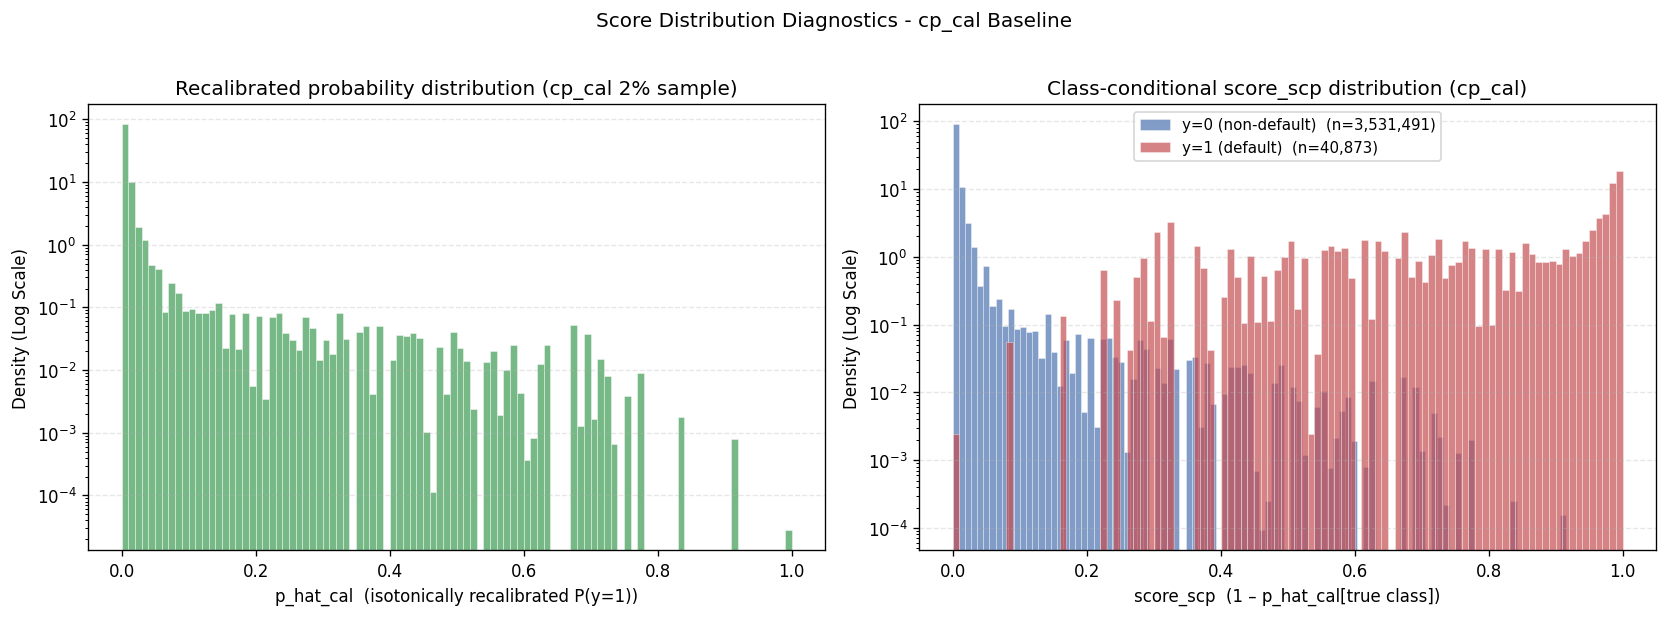


Computing PSI (score_scp) for each test split vs cp_cal baseline ...


,PSI,Bins,Siddiqi Band,Y&N Bench (α=0.05),E[score_scp],Pos Rate (%)
Split,,,,,,
calibration (cp_cal),0.0000,-,Small (<0.10),n/a,0.01757,1.144%
test_subprime,0.0062,10,Small (<0.10),6.07e-06,0.02979,2.574%
test_normal,0.0891,10,Small (<0.10),5.86e-06,0.01909,1.553%
test_covid,0.1240,10,Moderate (0.10–0.25),8.94e-06,0.02062,1.693%
test_rate_hike,0.1988,10,Moderate (0.10–0.25),7.50e-06,0.01349,1.052%



Note: at these diagnostic sample sizes the α=0.05 no-shift benchmark is ≤ 8.94e-06,
i.e. the 0.10 rule-of-thumb edge is ≈ 11,191× the benchmark. A formal shift test would reject no-shift for essentially any nonzero PSI. PSI is reported as a descriptive magnitude.


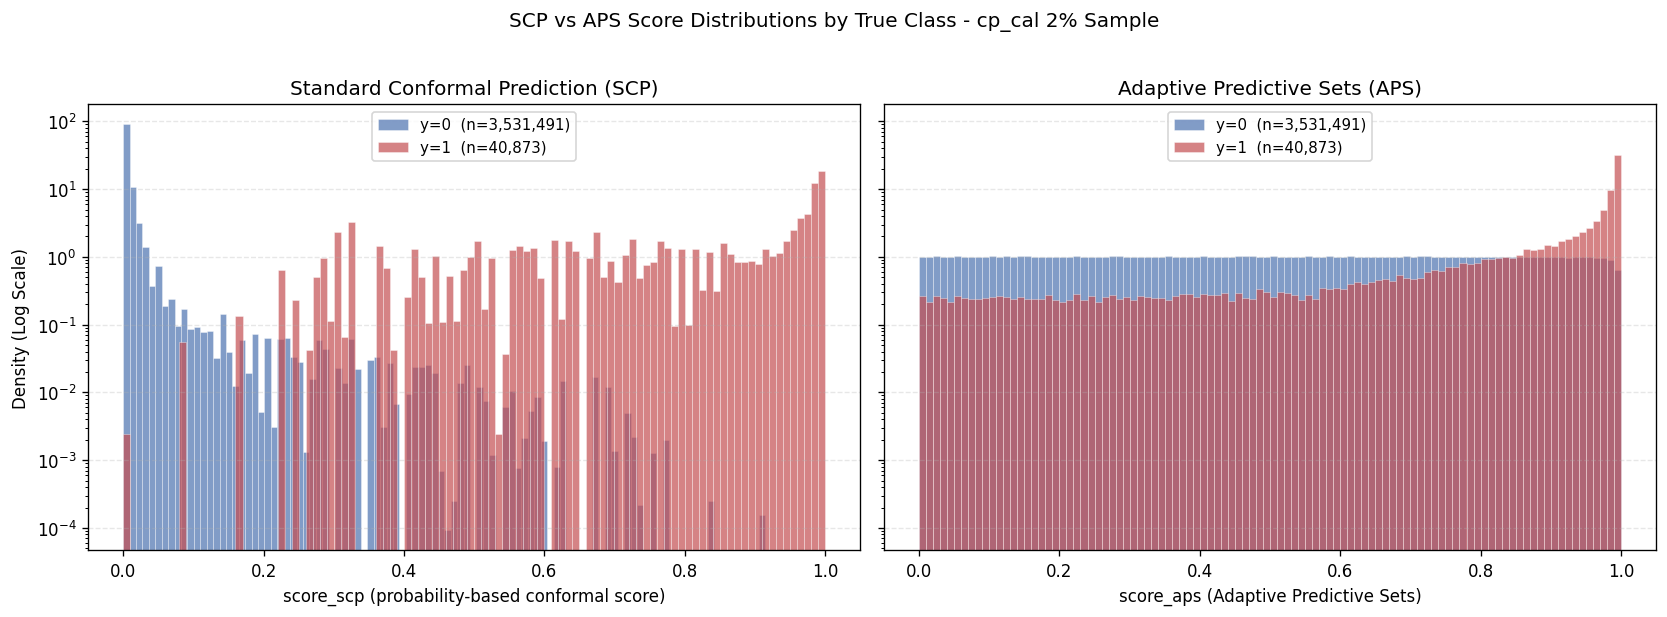

46976

In [ ]:
import pandas as pd

def compute_psi(
    scores_base: np.ndarray,
    scores_test: np.ndarray,
    n_bins: int = 10,
    eps: float = 1e-8,
) -> tuple[float, int]:
    """
    Population Stability Index (PSI) between two score distributions.

    Bin boundaries are derived from equal-frequency percentiles of scores_base.
    When scores_base has few distinct values (e.g. PAVA flat segments on an
    imbalanced dataset), np.unique may reduce the actual bin count below n_bins.
    The function warns when this occurs and returns the actual bin count so
    callers can assess comparability to standard n_bins-bin heuristic thresholds.

    PSI = Σ_b (p_base_b - p_test_b) * ln(p_base_b / p_test_b)

    With bin boundaries fixed from the base distribution, this is the Jeffreys (symmetric KL)
    divergence KL(base‖test) + KL(test‖base) and equals the standard credit-scoring convention
    Σ (Actual - Expected) * ln(Actual / Expected) (Yurdakul & Naranjo, 2020).

    Reference note:
        Descriptive diagnostic only. The 0.10/0.25 bands are an industry rule of thumb (Siddiqi
        2017), not definitive; a no-shift significance benchmark is given by Yurdakul & Naranjo
        (2020). See the §3 markdown.

    Parameters
    ----------
    scores_base : calibration distribution (cp_cal sample)
    scores_test : test split distribution
    n_bins      : requested number of equal-frequency bins (default 10);
                  actual bin count may be lower for discrete distributions
    eps         : small constant to avoid log(0) for empty bins

    Returns
    -------
    (psi, actual_bins) : (float, int)
        psi         - PSI value
        actual_bins - number of bins actually used (≤ n_bins)
    """
    quantiles   = np.linspace(0, 100, n_bins + 1)
    breaks      = np.unique(np.percentile(scores_base, quantiles))
    actual_bins = len(breaks) - 1

    if actual_bins < n_bins:
        print(f'  [PSI] Warning: {n_bins}-bin request collapsed to {actual_bins} bins '
              f'({len(np.unique(scores_base))} distinct score values in base). '
              f'PSI not directly comparable to {n_bins}-bin heuristic thresholds.')

    breaks[0]  = -np.inf
    breaks[-1] =  np.inf

    p_base = np.histogram(scores_base, bins=breaks)[0]
    p_test = np.histogram(scores_test, bins=breaks)[0]

    p_base = np.clip(p_base / p_base.sum(), eps, None)
    p_test = np.clip(p_test / p_test.sum(), eps, None)

    psi = float(np.sum((p_base - p_test) * np.log(p_base / p_test)))
    return psi, actual_bins

# ── Deterministic ~2% loan-level diagnostic sampler ──────────────────────────
def crc32_diag_sample(split_dir, iso_role_filter=None, keep=3, modulus=50):
    frames = []
    for f in sorted(split_dir.glob('*.parquet')):
        lf = pl.scan_parquet(str(f))
        if iso_role_filter is not None:
            lf = lf.filter(pl.col('iso_role') == iso_role_filter)
        df = lf.collect()
        if len(df) == 0:
            continue
        lsn = df['loan_sequence_number'].cast(pl.Utf8).to_list()
        keep_mask = np.fromiter(
            (zlib.crc32(s.encode()) % modulus == keep for s in lsn),
            dtype=bool, count=len(lsn),
        )
        sub = df.filter(pl.Series('_keep', keep_mask))
        if len(sub):
            frames.append(sub)
    if frames:
        return pl.concat(frames)
    any_file = next(iter(sorted(split_dir.glob('*.parquet'))), None)
    return pl.scan_parquet(str(any_file)).head(0).collect() if any_file else pl.DataFrame()

# ── Load score-drift reference: crc32 ≡ 3 (mod 50), a subset of cp_cal ───────
print('Loading 2% cp_cal sample for diagnostics ...')

cal_diag = crc32_diag_sample(SCORES_DIR / 'split=calibration', iso_role_filter='cp_cal')

print(f'cp_cal diagnostic sample: {len(cal_diag):,} rows')

s_scp_cal = cal_diag['score_scp'].to_numpy()
s_aps_cal = cal_diag['score_aps'].to_numpy()
y_cal     = cal_diag['y'].to_numpy()
p_cal_arr = cal_diag['p_hat_cal'].to_numpy()

# Plotting constants
COLOR_0 = '#4C72B0' # Cool Blue for non-default
COLOR_1 = '#C44E52' # Red for default

# ── Figure 1: p_hat_cal distribution and class-conditional score_scp ──────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(p_cal_arr, bins=100, color='#55A868', alpha=0.8, density=True, edgecolor='white', linewidth=0.3)
axes[0].set_xlabel('p_hat_cal  (isotonically recalibrated P(y=1))')
axes[0].set_ylabel('Density (Log Scale)')
axes[0].set_title('Recalibrated probability distribution (cp_cal 2% sample)')
axes[0].set_yscale('log')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

for cls, colour, label in [(0, COLOR_0, 'y=0 (non-default)'),
                           (1, COLOR_1, 'y=1 (default)')]:
    s = s_scp_cal[y_cal == cls]
    axes[1].hist(s, bins=100, color=colour, alpha=0.7, density=True, edgecolor='white', linewidth=0.3, label=f'{label}  (n={len(s):,})')

axes[1].set_xlabel('score_scp  (1 – p_hat_cal[true class])')
axes[1].set_ylabel('Density (Log Scale)')
axes[1].set_title('Class-conditional score_scp distribution (cp_cal)')
axes[1].legend(fontsize=9, loc='upper center')
axes[1].set_yscale('log')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

fig.suptitle('Score Distribution Diagnostics - cp_cal Baseline', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'score_distributions_nb05a.png', dpi=150, bbox_inches='tight')
plt.show()

# ── PSI for each test split vs cp_cal baseline ────────────────────────────────
print('\nComputing PSI (score_scp) for each test split vs cp_cal baseline ...')

from scipy.stats import chi2
from IPython.display import display

PSI_BENCH_ALPHA = 0.05

def psi_band(v) -> str:
    if v is None or not np.isfinite(v):
        return 'n/a'
    if v < 0.10:
        return 'Small (<0.10)'
    if v <= 0.25:
        return 'Moderate (0.10–0.25)'
    return 'Substantial (>0.25)'

def psi_bench(n_base: int, n_test: int, n_bins: int, alpha: float = PSI_BENCH_ALPHA) -> float:
    if (n_bins is None) or (n_bins < 2) or (n_base <= 0) or (n_test <= 0):
        return float('nan')
    return (1.0 / n_base + 1.0 / n_test) * float(chi2.ppf(1.0 - alpha, df=n_bins - 1))

PSI_BENCH: dict[str, float] = {}
n_base_diag = int(len(s_scp_cal))

table_rows = []

# Baseline statistics from cp_cal sample
table_rows.append({
    "Split": "calibration (cp_cal)",
    "PSI": 0.0,
    "Bins": "-",
    "Siddiqi Band": psi_band(0.0),
    "Y&N Bench (α=0.05)": float('nan'),
    "E[score_scp]": float(s_scp_cal.mean()),
    "Pos Rate (%)": float(y_cal.mean() * 100)
})

for split_name in ['test_subprime', 'test_normal', 'test_covid', 'test_rate_hike']:
    test_dir = SCORES_DIR / f'split={split_name}'
    if not test_dir.exists():
        print(f'  {split_name}: score files not found - skipping')
        continue

    test_diag = crc32_diag_sample(test_dir)
    s_test  = test_diag['score_scp'].to_numpy()
    y_test  = test_diag['y'].to_numpy()
    n_test  = int(len(s_test))

    psi, actual_bins = compute_psi(s_scp_cal, s_test, n_bins=10)
    bench = psi_bench(n_base_diag, n_test, actual_bins)

    PSI_BENCH[split_name] = bench

    table_rows.append({
        "Split": split_name,
        "PSI": psi,
        "Bins": actual_bins,
        "Siddiqi Band": psi_band(psi),
        "Y&N Bench (α=0.05)": bench,
        "E[score_scp]": float(s_test.mean()),
        "Pos Rate (%)": float(y_test.mean() * 100)
    })

    del test_diag, s_test, y_test
    gc.collect()

# Render PSI Table
df_psi = pd.DataFrame(table_rows).set_index("Split")

display(
    df_psi.style.format({
        "PSI": "{:.4f}",
        "Y&N Bench (α=0.05)": "{:.2e}",
        "E[score_scp]": "{:.5f}",
        "Pos Rate (%)": "{:.3f}%"
    }, na_rep="n/a")
    .set_caption("Population Stability Index (PSI) vs Calibration Baseline")
)

_finite_bench = [b for b in PSI_BENCH.values() if np.isfinite(b) and b > 0]
if _finite_bench:
    _max_bench = max(_finite_bench)
    if _max_bench < 0.10:
        _ratio = 0.10 / _max_bench
        print(f'\nNote: at these diagnostic sample sizes the α={PSI_BENCH_ALPHA} no-shift benchmark '
              f'is ≤ {_max_bench:.2e},')
        print(f'i.e. the 0.10 rule-of-thumb edge is ≈ {_ratio:,.0f}× the benchmark. A formal '
              f'shift test would reject no-shift for essentially any nonzero PSI. PSI is reported as a '
              f'descriptive magnitude.')

# ── Figure 2: APS vs SCP score comparison plot (cp_cal 2% sample) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# SCP Plot
for cls, alpha, label in [(0, 0.7, 'y=0'), (1, 0.7, 'y=1')]:
    axes[0].hist(s_scp_cal[y_cal == cls], bins=100, density=True,
                 color=COLOR_0 if cls == 0 else COLOR_1, alpha=alpha,
                 edgecolor='white', linewidth=0.3, label=f'{label}  (n={int((y_cal==cls).sum()):,})')
axes[0].set_xlabel('score_scp (probability-based conformal score)')
axes[0].set_ylabel('Density (Log Scale)')
axes[0].set_title('Standard Conformal Prediction (SCP)')
axes[0].legend(fontsize=9, loc='upper center')
axes[0].grid(axis='y', alpha=0.3, linestyle='--')

# APS Plot
for cls, alpha, label in [(0, 0.7, 'y=0'), (1, 0.7, 'y=1')]:
    axes[1].hist(s_aps_cal[y_cal == cls], bins=100, density=True,
                 color=COLOR_0 if cls == 0 else COLOR_1, alpha=alpha,
                 edgecolor='white', linewidth=0.3, label=f'{label}  (n={int((y_cal==cls).sum()):,})')
axes[1].set_xlabel('score_aps (Adaptive Predictive Sets)')
axes[1].set_title('Adaptive Predictive Sets (APS)')
axes[1].legend(fontsize=9, loc='upper center')
axes[1].grid(axis='y', alpha=0.3, linestyle='--')

# Ensure log scale for both
axes[0].set_yscale('log')
axes[1].set_yscale('log')

fig.suptitle('SCP vs APS Score Distributions by True Class - cp_cal 2% Sample', fontsize=12, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'scp_vs_aps_scores_nb05a.png', dpi=150, bbox_inches='tight')
plt.show()

del cal_diag, s_scp_cal, s_aps_cal, y_cal, p_cal_arr
gc.collect()

> **Inference note.** The printed “essentially any nonzero PSI” means that **each observed
> PSI value** exceeds the Yurdakul–Naranjo independent-multinomial 5% reference. That
> reference is not a calibrated hypothesis test for the dependent loan-month panel; as said, PSI
> is used descriptively in the thesis.

---
## Section 4 · NB05a Artefact Manifest

In [ ]:
# The manifest carries:
#   - calibration-quality diagnostics (Brier and AUROC pre/post isotonic recalibration),
#   - per-split PSI, mean score_scp, and positive-rate diagnostics, and
#   - the score-file split inventory.

with open(CALIBRATOR_META_PATH) as f:
    _cal_meta = json.load(f)

# Extract diagnostics from table_rows created in the previous cell
PSI_VALUES = {row['Split']: row['PSI'] for row in table_rows if row['Split'] != 'calibration (cp_cal)'}
ESCORE_VALUES = {row['Split']: row['E[score_scp]'] for row in table_rows if row['Split'] != 'calibration (cp_cal)'}
POSRATE_VALUES = {row['Split']: row['Pos Rate (%)'] for row in table_rows if row['Split'] != 'calibration (cp_cal)'}

score_manifest = {
    # ── Calibration diagnostics ───────────────────────────────────────────────
    "calibration_diagnostics": {
        "brier_pre_oos"   : round(float(_cal_meta.get("brier_score_before_oos", _cal_meta["brier_score_before"])), 6),
        "brier_post"      : round(float(_cal_meta["brier_score_after_oos"]), 6),
        "auroc_pre"       : round(float(_cal_meta["auroc_raw"]),   6),
        "auroc_post"      : round(float(_cal_meta["auroc_after"]), 6),
        "auroc_delta"     : round(float(_cal_meta["auroc_delta"]), 6),
        "pava_breakpoints": int(_cal_meta["n_breakpoints"]),
    },

    # ── Per-split score diagnostics (re-emitted into cp_manifest by NB05b) ──────
    "psi_score_scp"    : {k: round(v, 6) for k, v in PSI_VALUES.items()},
    "mean_score_scp"   : {k: round(v, 8) for k, v in ESCORE_VALUES.items()},
    "positive_rate_pct": {k: round(v, 6) for k, v in POSRATE_VALUES.items()},

    # ── Score-file split inventory ────────────────────────────────────────────
    "score_splits": {
        split_name: {
            "n_rows": WRITTEN_ROW_COUNTS[split_name],
            "score_dir": str(SCORES_DIR / f"split={split_name}"),
            "obs_years": years,
        }
        for split_name, years in SPLITS_TO_SCORE
    },
}

# Write manifest to MANIFEST_DIR (SCORE_MANIFEST_PATH defined in §0.3)
SCORE_MANIFEST_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(SCORE_MANIFEST_PATH, "w") as f:
    json.dump(score_manifest, f, indent=2)

print(f"✓  score_manifest.json written → {SCORE_MANIFEST_PATH}")
print(f"   Brier OOS pre/post : {score_manifest['calibration_diagnostics']['brier_pre_oos']:.4f}  →  "
      f"{score_manifest['calibration_diagnostics']['brier_post']:.4f}")
print(f"   AUROC pre/post : {score_manifest['calibration_diagnostics']['auroc_pre']:.4f}  →  "
      f"{score_manifest['calibration_diagnostics']['auroc_post']:.4f}  "
      f"(Δ = {score_manifest['calibration_diagnostics']['auroc_delta']:+.4f})")
print(f"   PSI (score_scp)  [band: Siddiqi 2017; bench: Yurdakul & Naranjo 2020, α={PSI_BENCH_ALPHA}]:")

for split_name, psi_val in PSI_VALUES.items():
    row = next(r for r in table_rows if r['Split'] == split_name)
    bins_used = row.get('Bins', "-")
    band      = row.get('Siddiqi Band', psi_band(psi_val))
    bench     = PSI_BENCH.get(split_name, float("nan"))
    bench_str = f"{bench:.2e}" if np.isfinite(bench) else "n/a"
    print(f"     {split_name:<25} {psi_val:.4f}  (bins: {bins_used})  band: {band}  bench(.05): {bench_str}")

✓  score_manifest.json written → /content/drive/MyDrive/master_thesis/manifests/score_manifest.json
   Brier OOS pre/post : 0.0643  →  0.0086
   AUROC pre/post : 0.9113  →  0.9114  (Δ = -0.0001)
   PSI (score_scp)  [band: Siddiqi 2017; bench: Yurdakul & Naranjo 2020, α=0.05]:
     test_subprime             0.0062  (bins: 10)  band: Small (<0.10)  bench(.05): 6.07e-06
     test_normal               0.0891  (bins: 10)  band: Small (<0.10)  bench(.05): 5.86e-06
     test_covid                0.1240  (bins: 10)  band: Moderate (0.10–0.25)  bench(.05): 8.94e-06
     test_rate_hike            0.1988  (bins: 10)  band: Moderate (0.10–0.25)  bench(.05): 7.50e-06


> **AUROC metadata note.** In `score_manifest.json`, `auroc_pre` and `auroc_post`
> are the in-sample `iso_fit` AUROCs from §1.1, whereas `auroc_delta` is the OOS
> `cp_cal` change from §1.3. The OOS ranking diagnostic used downstream is
> `auroc_delta`; the stored absolute pair should not be used to reconstruct it.

## Literature and Documentation Appendix

---

### Gradient Boosting and LightGBM

- Friedman, J. H. (2001). Greedy function approximation: A gradient boosting machine. The Annals of Statistics, 29(5), 1189–1232. https://doi.org/10.1214/aos/1013203451

- Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A highly efficient gradient boosting decision tree. Advances in Neural Information Processing Systems, 30, 3146–3154. https://proceedings.neurips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b7Abstract.html

---

### Isotonic Regression and Probability Calibration

- Ayer, M., Brunk, H. D., Ewing, G. M., Reid, W. T., & Silverman, E. (1955). An empirical distribution function for sampling with incomplete information. The Annals of Mathematical Statistics, 26(4), 641–647. https://doi.org/10.1214/aoms/1177728423

- Barlow, R. E., Bartholomew, D. J., Bremner, J. M., & Brunk, H. D. (1972). Statistical inference under order restrictions: The theory and application of isotonic regression. John Wiley & Sons.

- Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. Proceedings of the 22nd International Conference on Machine Learning, 625–632. https://doi.org/10.1145/1102351.1102430

- DeGroot, M. H., & Fienberg, S. E. (1983). The comparison and evaluation of forecasters.
*Journal of the Royal Statistical Society. Series D (The Statistician), 32*(1), 12–22.
https://doi.org/10.2307/2987588

- Guo, C., Pleiss, G., Sun, Y., & Weinberger, K. Q. (2017). On calibration of modern neural networks. In D. Precup & Y. W. Teh (Eds.), Proceedings of the 34th international conference on machine learning (pp. 1321–1330, Vol. 70). PMLR. https://proceedings.mlr.press/v70/guo17a.html

- Zadrozny, B., & Elkan, C. (2002). Transforming classifier scores into accurate multiclass probability estimates. Proceedings of the Eighth ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 694–699. https://doi.org/10.1145/775047.775151

---

### Proper Scoring Rules

- Brier, G. W. (1950). Verification of forecasts expressed in terms of probability. Monthly Weather Review, 78(1), 1–3. https://journals.ametsoc.org/view/journals/mwre/78/1/1520-0493_1950_078_0001_vofeit_2_0_co_2.xml

- Gneiting, T., & Raftery, A. E. (2007). Strictly proper scoring rules, prediction, and estimation.
*Journal of the American Statistical Association, 102*(477), 359–378.
https://doi.org/10.1198/016214506000001437

---

### ROC Analysis

- Fawcett, T. (2006). An introduction to ROC analysis. Pattern Recognition Letters, 27(8), 861–874. https://doi.org/10.1016/j.patrec.2005.10.010

---

### Class Imbalance and Cost-Sensitive Learning

- Elkan, C. (2001). The foundations of cost-sensitive learning. In B. Nebel (Ed.), Proceedings of the seventeenth international joint conference on artificial intelligence (pp. 973–978, Vol. 2). Morgan Kaufmann.

- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. IEEE Transactions on Knowledge and Data Engineering, 21(9), 1263–1284. https://doi.org/10.1109/TKDE.2008.239

---

### Conformal Prediction

- Vovk, V. (2012). Conditional validity of inductive conformal predictors. In S. C. H. Hoi & W. Buntine (Eds.), Proceedings of the asian conference on machine learning (pp. 475–490, Vol. 25). PMLR. https://proceedings.mlr.press/v25/vovk12.html

- Vovk, V., Gammerman, A., & Shafer, G. (2005). Algorithmic learning in a random world (1st ed.). Springer. https://doi.org/10.1007/b106715

- Shafer, G., & Vovk, V. (2008). A tutorial on conformal prediction. Journal of Machine Learning Re-
search, 9(12), 371–421. https://www.jmlr.org/papers/v9/shafer08a.html

- Papadopoulos, H., Proedrou, K., Vovk, V., & Gammerman, A. (2002). Inductive confidence machines for regression. In T. Elomaa, H. Mannila, & H. Toivonen (Eds.), Machine learning: Ecml 2002 (pp. 345–356, Vol. 2430). Springer. https://doi.org/10.1007/3-540-36755-1_29

- Lei, J., G’Sell, M., Rinaldo, A., Tibshirani, R. J., & Wasserman, L. (2018). Distribution-free predictive inference for regression. Journal of the American Statistical Association, 113(523), 1094–1111. https://doi.org/10.1080/01621459.2017.1307116

- Lei, J., & Wasserman, L. (2014). Distribution-free prediction bands for non-parametric regression. Journal of the Royal Statistical Society Series B: Statistical Methodology, 76(1), 71–96. https://doi.org/10.1111/rssb.12021

- Sadinle, M., Lei, J., & Wasserman, L. (2019). Least ambiguous set-valued classifiers with bounded error levels. Journal of the American Statistical Association, 114(525), 223–234. https://doi.org/10.1080/01621459.2017.1395341

- Romano, Y., Sesia, M., & Candès, E. J. (2020). Classification with valid and adaptive coverage. In H. Larochelle, M. Ranzato, R. Hadsell, M.-F. Balcan, & H.-T. Lin (Eds.), Advances in neural information processing systems (pp. 3581–3591, Vol. 33). Curran Associates, Inc. https://proceedings.neurips.cc/paper/2020/hash/244edd7e85dc81602b7615cd705545f5-Abstract.html
---

### Credit Scoring, Scorecards & PSI Monitoring

- Siddiqi, N. (2017). Intelligent credit scoring: Building and implementing better credit risk scorecards (2nd ed.). John Wiley & Sons. https://doi.org/10.1002/9781119282396

- Yurdakul, B., & Naranjo, J. D. (2020). Statistical properties of the population stability index. Journal
of Risk Model Validation, 14(4), 89–100. https://doi.org/10.21314/JRMV.2020.227

---

### Software Documentation

- LightGBM Developers. (n.d.). *Parameters: `scale_pos_weight`.* LightGBM documentation. https://lightgbm.readthedocs.io/en/latest/Parameters.html

- scikit-learn Developers. (n.d.). *sklearn.isotonic.IsotonicRegression*.
Retrieved May 2026, from https://scikit-learn.org/stable/modules/generated/sklearn.isotonic.IsotonicRegression.html